<a href="https://colab.research.google.com/github/saloni01-stack/solar-power-prediction/blob/main/solar_power_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

gen=pd.read_csv("Plant_1_Generation_Data.csv")
weather=pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

print(gen.head())
print(weather.head())

          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  
             DATE_TIME  PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  \
0  2020-05-15 00:00:00   4135001  HmiyD2TTLFNqkNe            25.184316   
1  2020-05-15 00:15:00   4135001  HmiyD2TTLFNqkNe            25.084589   
2  2020-05-15 00:30:00   4135001  HmiyD2TTLFNqkNe            24.935753   
3  2020-05-15 00:45:00   4135001  HmiyD2TTLFNqkNe            24.846130   
4  2020-05-15 01:00:00   4135

In [5]:
gen["DATE_TIME"]=pd.to_datetime(gen["DATE_TIME"])
weather["DATE_TIME"]=pd.to_datetime(weather["DATE_TIME"])

gen_total=gen.groupby("DATE_TIME")[["DC_POWER","AC_POWER"]].sum().reset_index()

weather=weather[["DATE_TIME","AMBIENT_TEMPERATURE","MODULE_TEMPERATURE","IRRADIATION"]]

df = pd.merge(gen_total,  weather , on="DATE_TIME")

print(df.shape)
print(df.isnull().sum())
print(df.head())

(3157, 6)
DATE_TIME              0
DC_POWER               0
AC_POWER               0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64
            DATE_TIME  DC_POWER  AC_POWER  AMBIENT_TEMPERATURE  \
0 2020-05-15 00:00:00       0.0       0.0            25.184316   
1 2020-05-15 00:15:00       0.0       0.0            25.084589   
2 2020-05-15 00:30:00       0.0       0.0            24.935753   
3 2020-05-15 00:45:00       0.0       0.0            24.846130   
4 2020-05-15 01:00:00       0.0       0.0            24.621525   

   MODULE_TEMPERATURE  IRRADIATION  
0           22.857507          0.0  
1           22.761668          0.0  
2           22.592306          0.0  
3           22.360852          0.0  
4           22.165423          0.0  


/tmp/ipykernel_799/3618677098.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  gen["DATE_TIME"]=pd.to_datetime(gen["DATE_TIME"])


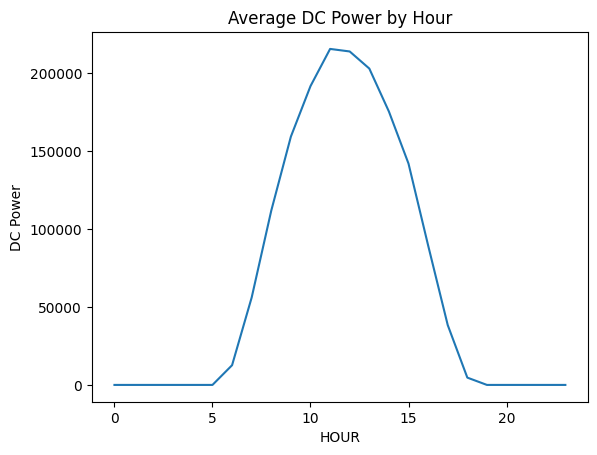

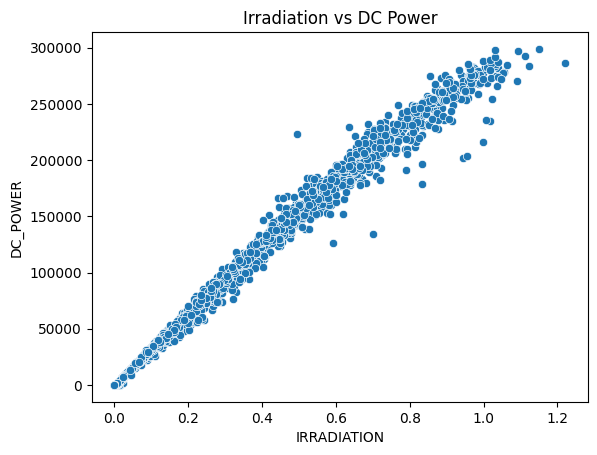

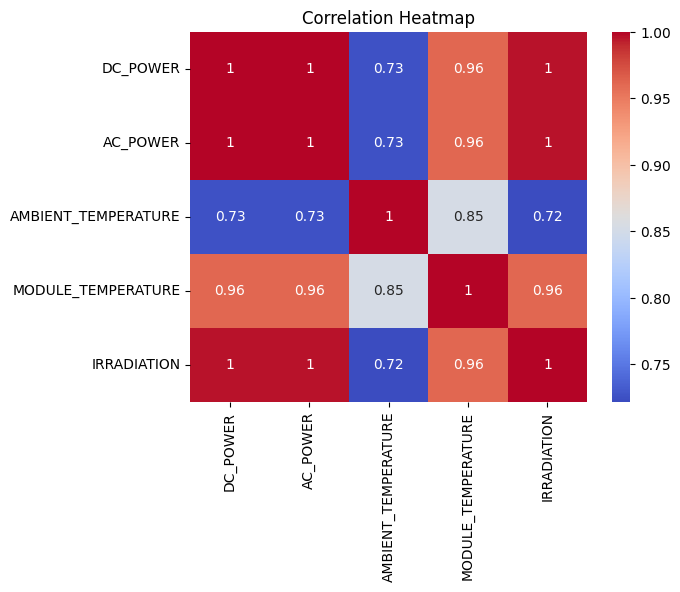

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df["HOUR"] = df["DATE_TIME"].dt.hour

# 1. Average power by hour of day
df.groupby("HOUR")["DC_POWER"].mean().plot(title="Average DC Power by Hour")
plt.ylabel("DC Power")
plt.show()

# 2. Irradiation vs power
sns.scatterplot(x="IRRADIATION", y="DC_POWER", data=df)
plt.title("Irradiation vs DC Power")
plt.show()

# 3. Correlation heatmap
cols = ["DC_POWER", "AC_POWER", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X = df[["AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]]
y = df["DC_POWER"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for model in [LinearRegression(), RandomForestRegressor(n_estimators=100, random_state=42)]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(type(model).__name__, "| R2:", round(r2_score(y_test, pred), 3), "| MAE:", round(mean_absolute_error(y_test, pred), 1))

LinearRegression | R2: 0.994 | MAE: 4000.7
RandomForestRegressor | R2: 0.995 | MAE: 2872.3
